In [27]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [26]:
titanic = pd.read_csv('data/titanic.csv')
titanic.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [20]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='str')

In [21]:
titanic.shape

(891, 12)

In [22]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [23]:
titanic['Age'].value_counts()

Age
28.00    202
24.00     30
22.00     27
18.00     26
19.00     25
        ... 
24.50      1
0.67       1
0.42       1
34.50      1
74.00      1
Name: count, Length: 88, dtype: int64

cabin titile have lot of nan value over 600 by drop removing the column

In [28]:


titanic["Age"] = titanic["Age"].fillna(titanic['Age'].median())
titanic["Embarked"] = titanic["Embarked"].fillna(titanic['Embarked'].mode()[0])

titanic["FamilySize"] = titanic['SibSp'] + titanic['Parch'] + 1
titanic["Age"].isnull().sum()
titanic["Embarked"].isnull().sum()

np.int64(0)

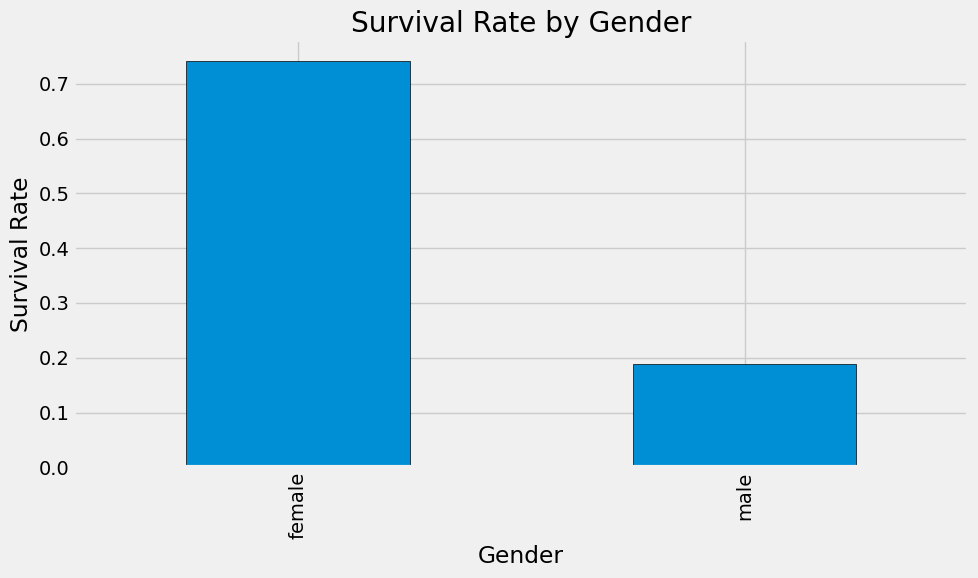

In [29]:
fig, ax = plt.subplots(figsize=(10,6))
survival_gender = titanic.groupby("Sex")["Survived"].mean()

survival_gender.plot(kind='bar', edgecolor='black')
ax.set_title("Survival Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Survival Rate")
fig.savefig("plots/Survival_Rate_by_Gender.png")

plt.tight_layout()
 
plt.show()

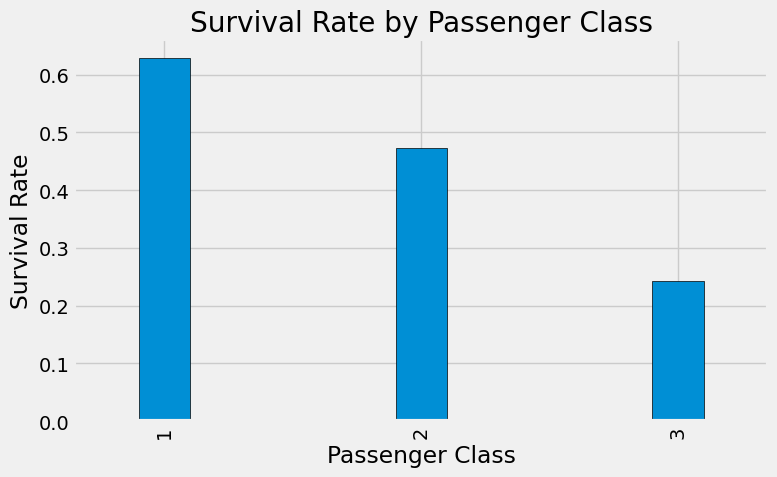

In [30]:
fig, ax = plt.subplots(figsize=(8,5))

survival_class = titanic.groupby("Pclass")["Survived"].mean()
survival_class.plot(kind='bar', edgecolor='black', width=.2)

ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
fig.savefig("plots/Survival_Rate_by_Passenger_class.png")

plt.tight_layout()

plt.show()  

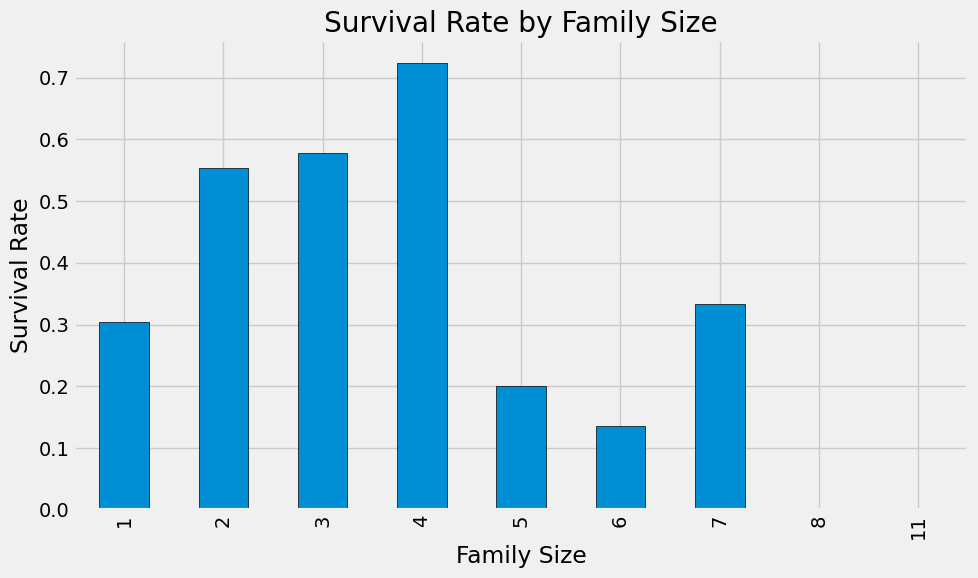

In [31]:
fig, ax = plt.subplots(figsize=(10, 6)) 
family_survival = titanic.groupby("FamilySize")["Survived"].mean()
                       
family_survival.plot(kind='bar', edgecolor='black')
                               
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("Family Size")
ax.set_ylabel("Survival Rate")
fig.savefig("plots/Survival_Rate_by_family_size.png")

plt.tight_layout()

plt.show()

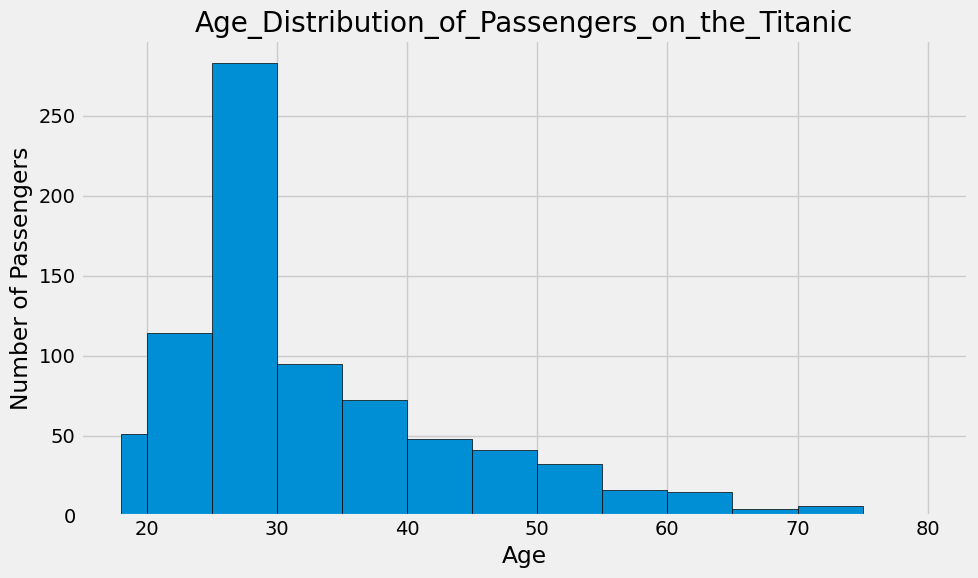

In [32]:

fig, ax = plt.subplots(figsize=(10,6))

bins=[18,20,25,30,35,40,45,50,55,60,65,70,75,80]
ax.hist(titanic["Age"], bins=bins, edgecolor='black')
ax.set_title("Age_Distribution_of_Passengers_on_the_Titanic")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Passengers")
fig.savefig("plots/Age_Distribution_of_Passengers.png")

plt.tight_layout()

plt.show()

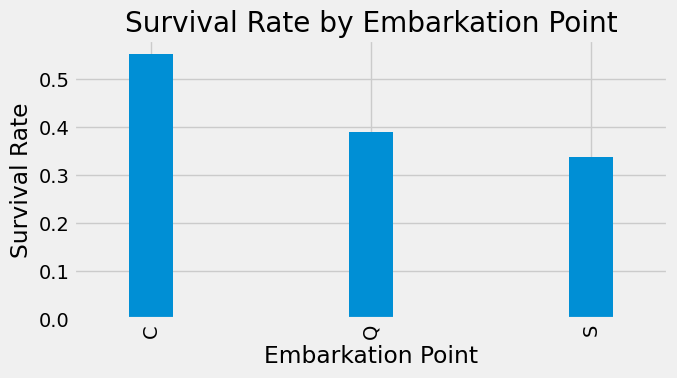

In [33]:
fig, ax = plt.subplots(figsize=(7,4))

embarked_survival = titanic.groupby("Embarked")["Survived"].mean()
embarked_survival.plot(kind='bar', width = .2)

ax.set_title("Survival Rate by Embarkation Point")
ax.set_xlabel("Embarkation Point")
ax.set_ylabel("Survival Rate")
fig.savefig("plots/Survival_Rate_by_Embarkation_Point.png")
plt.tight_layout()
plt.show()
